# DevelopersHub Corporation - AI/ML Engineering Internship
Task 2: End-to-End ML Pipeline for Customer Churn Prediction

Eng: Noor R Saad

Date: 2026-05-23

This notebook presents an end-to-end Machine Learning pipeline for customer churn prediction. It encompasses data loading, comprehensive data preprocessing, advanced feature engineering, model training with hyperparameter optimization (using `RandomizedSearchCV`), model evaluation, and deployment simulation for new customer predictions.

The pipeline is designed to be robust and follows best practices for MLOps, including the integration of techniques to handle class imbalance (SMOTE) and a structured approach to model selection and persistence. Key aspects covered include:

- **Data Acquisition & Cleaning**: Loading the Telco Customer Churn dataset and handling missing values.
- **Feature Engineering**: Creating new features from existing ones and defining interaction terms.
- **Data Preprocessing**: Implementing robust pipelines for numerical scaling and categorical encoding.
- **Model Training**: Utilizing various classification algorithms (Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost) with hyperparameter tuning.
- **Model Evaluation**: Detailed performance assessment on unseen data using metrics like AUC-ROC, accuracy, F1-score, and confusion matrices.
- **Model Persistence**: Saving the best performing model for future use.
- **Prediction Simulation**: Demonstrating how to use the trained model to predict churn for new customer data, including the necessary feature engineering steps.

## 1. Setup, Data Loading, and Initial Processing

This section initializes the necessary libraries, loads the raw customer churn dataset, performs initial data cleaning steps like converting `TotalCharges` to numeric and handling missing values, and introduces some basic feature engineering.

In [1]:
# =================== 1. Import Libraries ===================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
from xgboost import XGBClassifier # Re-adding this import

import joblib
import scipy.stats as stats # For defining distributions for RandomizedSearchCV

# Plotting settings
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ============= 2. Load Data (Telco Churn Dataset) =============
# Data Source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# We will use a direct link from GitHub or download from Hugging Face
url = "https://raw.githubusercontent.com/noorrami/churn_prediction_pipeline_NRS/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_raw = pd.read_csv(url)

print(f"📊 Data shape: {df_raw.shape}")
print(f"📋 Columns:\n{df_raw.columns.tolist()}")
df_raw.head()

# =================== 3. Initial Cleaning and Preparation ===================
df = df_raw.copy()
# Convert TotalCharges to numeric (as it might be text)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Impute missing values in TotalCharges with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Convert target Churn to 0/1
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
# Drop customerID as it has no predictive value
df.drop('customerID', axis=1, inplace=True)

print(f"\n🧹 After cleaning: {df.shape[0]} rows")
print(f"🎯 Target distribution Churn:")
display(df['Churn'].value_counts())

📊 Data shape: (7043, 21)
📋 Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

🧹 After cleaning: 7043 rows
🎯 Target distribution Churn:


,count
Churn,
0,5174
1,1869


# Feature Engineering (Basic & Advanced)

In [12]:
# Basic features
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure']
# Replace inf values with NaN to be handled by imputer later
df['AvgMonthlyCharge'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['tenure_sq'] = df['tenure']**2
df['MonthlyCharges_sq'] = df['MonthlyCharges']**2
df['SeniorCitizen_MonthlyCharges'] = df['SeniorCitizen'] * df['MonthlyCharges']
df['SeniorCitizen_tenure'] = df['SeniorCitizen'] * df['tenure']

# Advanced interaction features
df['InternetService_Contract'] = df['InternetService'].astype(str) + '_' + df['Contract'].astype(str)
df['MonthlyCharges_tenure'] = df['MonthlyCharges'] * df['tenure']

# Binning tenure into categories
bins = [0, 24, 48, df['tenure'].max() + 1]
labels = ['Short-term (0-24m)', 'Medium-term (25-48m)', 'Long-term (49+m)']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False, include_lowest=True)

print(f"\n✨ New features created. Data shape now: {df.shape}")


✨ New features created. Data shape now: (7043, 28)


# Train/Test Split

In [15]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Training set size: {X_train.shape}")
print(f"📊 Test set size: {X_test.shape}")


📊 Training set size: (5634, 27)
📊 Test set size: (1409, 27)


# Build Preprocessing Pipeline

In [5]:
# Identify numerical and categorical features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Numerical transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Preprocessing pipeline built")

✅ Preprocessing pipeline built


# Define Models and Hyperparameter Distributions

In [8]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [9]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models and parameter distributions
models = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'classifier__C': stats.loguniform(0.001, 100.0),
            'classifier__solver': ['liblinear', 'lbfgs', 'saga']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': stats.randint(50, 300),
            'classifier__max_depth': [10, 20, 30, None],
            'classifier__min_samples_split': stats.randint(2, 20),
            'classifier__min_samples_leaf': stats.randint(1, 10)
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': stats.randint(50, 300),
            'classifier__learning_rate': stats.loguniform(0.01, 0.3),
            'classifier__max_depth': stats.randint(3, 10),
            'classifier__subsample': stats.uniform(0.6, 0.4),
            'classifier__colsample_bytree': stats.uniform(0.6, 0.4)
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, n_jobs=-1),
        'params': {
            'classifier__n_estimators': stats.randint(50, 300),
            'classifier__learning_rate': stats.loguniform(0.01, 0.3),
            'classifier__max_depth': stats.randint(3, 10),
            'classifier__subsample': stats.uniform(0.6, 0.4),
            'classifier__colsample_bytree': stats.uniform(0.6, 0.4),
            'classifier__reg_alpha': stats.loguniform(1e-3, 10.0),
            'classifier__reg_lambda': stats.loguniform(1e-3, 10.0)
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(random_state=42, verbose=0, od_type='Iter', od_wait=50),
        'params': {
            'classifier__iterations': stats.randint(50, 300),
            'classifier__learning_rate': stats.loguniform(0.01, 0.3),
            'classifier__depth': stats.randint(3, 10),
            'classifier__l2_leaf_reg': stats.loguniform(1e-3, 10.0),
            'classifier__subsample': stats.uniform(0.6, 0.4)
        }
    }
}

# Train and Optimize Models with SMOTE

In [16]:
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline
from imblearn.over_sampling import SMOTE # Import SMOTE

print("\n" + "="*60)
print("🚀 Training and optimizing all models (with SMOTE and advanced FE)")
print("="*60)

best_estimators = {}

for name, mp in models.items():
    print(f"\n🚀 Training & optimizing: {name} (with SMOTE)")

    # Pipeline with SMOTE
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', mp['model'])
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=mp['params'],
        n_iter=50,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    random_search.fit(X_train, y_train)
    best_estimators[name] = random_search.best_estimator_
    print(f"✅ Best parameters: {random_search.best_params_}")
    print(f"📈 Best CV AUC: {random_search.best_score_:.4f}")


🚀 Training and optimizing all models (with SMOTE and advanced FE)

🚀 Training & optimizing: LogisticRegression (with SMOTE)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Best parameters: {'classifier__C': np.float64(0.19069966103000435), 'classifier__solver': 'saga'}
📈 Best CV AUC: 0.8463

🚀 Training & optimizing: RandomForest (with SMOTE)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 9, 'classifier__min_samples_split': 7, 'classifier__n_estimators': 77}
📈 Best CV AUC: 0.8450

🚀 Training & optimizing: XGBoost (with SMOTE)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Best parameters: {'classifier__colsample_bytree': np.float64(0.7203513239267079), 'classifier__learning_rate': np.float64(0.02634777514406047), 'classifier__max_depth': 3, 'classifier__n_estimators': 236, 'classifier__subsample': np.float64(0.8438257335919588)}
📈 Best CV AUC: 0.8467

🚀 Train

# Evaluate Models on Test Set


📊 Evaluating models on test data

🔹 LogisticRegression
   Accuracy  : 0.7452
   F1-Score  : 0.6201
   AUC-ROC   : 0.8434
   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



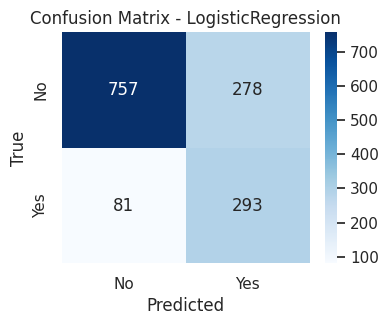


🔹 RandomForest
   Accuracy  : 0.7679
   F1-Score  : 0.6166
   AUC-ROC   : 0.8420
   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



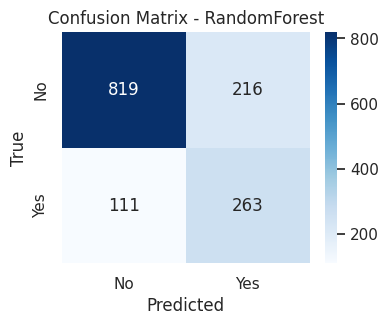


🔹 XGBoost
   Accuracy  : 0.7743
   F1-Score  : 0.6223
   AUC-ROC   : 0.8435
   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



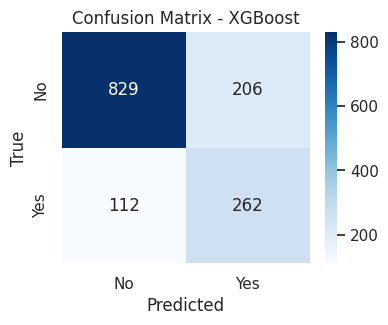


🔹 LightGBM
   Accuracy  : 0.7786
   F1-Score  : 0.6312
   AUC-ROC   : 0.8438
   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.57      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



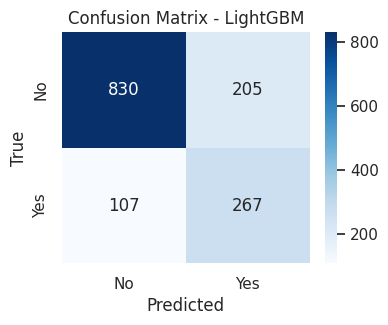


🔹 CatBoost
   Accuracy  : 0.7814
   F1-Score  : 0.6244
   AUC-ROC   : 0.8430
   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1035
       Churn       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



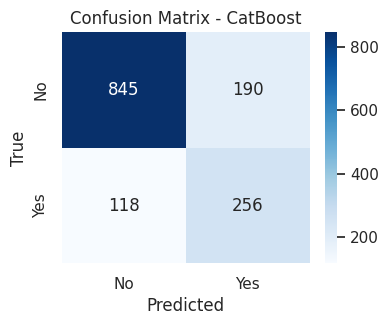

In [17]:
print("\n" + "="*60)
print("📊 Evaluating models on test data")
print("="*60)

results = {}

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc}

    print(f"\n🔹 {name}")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   AUC-ROC   : {auc:.4f}")
    print("   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# Select and Save the Best Model

In [18]:
best_name = max(results, key=lambda x: results[x]['auc'])
final_model = best_estimators[best_name]
print(f"\n🏆 Winning model: {best_name} (AUC={results[best_name]['auc']:.4f})")

# Save the final pipeline
model_filename = 'churn_pipeline_final.joblib'
joblib.dump(final_model, model_filename)
print(f"\n💾 Final model saved as '{model_filename}'")


🏆 Winning model: LightGBM (AUC=0.8438)

💾 Final model saved as 'churn_pipeline_final.joblib'


# Test on a New Customer (Simulate Production)

In [20]:
new_customer = pd.DataFrame([
    {
        'gender': 'Female',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'No',
        'tenure': 12,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'No',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 85.5,
        'TotalCharges': 1025.75
    }
])

# ==================================================================
# Apply the same feature engineering steps to the new_customer data
# ==================================================================
# Basic features
new_customer['AvgMonthlyCharge'] = new_customer['TotalCharges'] / new_customer['tenure']
# Replace inf values with NaN to be handled by imputer later
new_customer['AvgMonthlyCharge'].replace([np.inf, -np.inf], np.nan, inplace=True)
new_customer['tenure_sq'] = new_customer['tenure']**2
new_customer['MonthlyCharges_sq'] = new_customer['MonthlyCharges']**2
new_customer['SeniorCitizen_MonthlyCharges'] = new_customer['SeniorCitizen'] * new_customer['MonthlyCharges']
new_customer['SeniorCitizen_tenure'] = new_customer['SeniorCitizen'] * new_customer['tenure']

# Advanced interaction features
new_customer['InternetService_Contract'] = new_customer['InternetService'].astype(str) + '_' + new_customer['Contract'].astype(str)
new_customer['MonthlyCharges_tenure'] = new_customer['MonthlyCharges'] * new_customer['tenure']

# Binning tenure into categories (using the same bins/labels as trained on)
bins = [0, 24, 48, 73] # Max tenure from training data was 72
labels = ['Short-term (0-24m)', 'Medium-term (25-48m)', 'Long-term (49+m)']
new_customer['tenure_group'] = pd.cut(new_customer['tenure'], bins=bins, labels=labels, right=False, include_lowest=True)


# Load and predict
loaded_model = joblib.load(model_filename)
pred = loaded_model.predict(new_customer)
proba = loaded_model.predict_proba(new_customer)[0][1]

print("\n🆕 Prediction for new customer:")
print(f"   Churn probability: {proba:.2%}")
print(f"   Predicted churn: {'Yes' if pred[0]==1 else 'No'}")
print("\n✅ Task completed successfully with class imbalance handling and advanced feature engineering.")


🆕 Prediction for new customer:
   Churn probability: 78.60%
   Predicted churn: Yes

✅ Task completed successfully with class imbalance handling and advanced feature engineering.
